In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import phi2D_utilities as utils;
from matplotlib.animation import FuncAnimation

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
simulation_path = "/zhisongqu_data/seth/GYSELA/raw/fresh_batch_8.0/DN_FLUXDRIVEN_GAM_CIRCULARTEST_Q3.5"

<>:27: SyntaxWarning: invalid escape sequence '\P'
<>:27: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_1054753/218777295.py:27: SyntaxWarning: invalid escape sequence '\P'
  axes.set_title(f"Poloidal Cross-Section of $\Phi$ at frame = {frame}");
/home/thur0011/GYSELA/custom_scripts/GYSELA_utils/post-processing/scripts/phi2D_utilities.py:212: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  return np.linspace(0, 2 * np.pi, phi2D_dataset.dims["theta"]);
/home/thur0011/GYSELA/custom_scripts/GYSELA_utils/post-processing/scripts/phi2D_utilities.py:216: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dat

Loaded frame 0 from Phi2D_d00000.h5.
Loaded frame 0 from Phi2D_d00000.h5.
Loaded frame 0 from Phi2D_d00000.h5.
Loaded frame 5 from Phi2D_d00005.h5.
Loaded frame 10 from Phi2D_d00010.h5.
Loaded frame 15 from Phi2D_d00015.h5.
Loaded frame 20 from Phi2D_d00020.h5.
Loaded frame 25 from Phi2D_d00025.h5.
Loaded frame 30 from Phi2D_d00030.h5.
Loaded frame 35 from Phi2D_d00035.h5.
Loaded frame 40 from Phi2D_d00040.h5.
Loaded frame 45 from Phi2D_d00045.h5.
Loaded frame 50 from Phi2D_d00050.h5.
Loaded frame 55 from Phi2D_d00055.h5.
Loaded frame 60 from Phi2D_d00060.h5.
Loaded frame 65 from Phi2D_d00065.h5.
Loaded frame 70 from Phi2D_d00070.h5.
Loaded frame 75 from Phi2D_d00075.h5.
Loaded frame 80 from Phi2D_d00080.h5.
Loaded frame 85 from Phi2D_d00085.h5.
Loaded frame 90 from Phi2D_d00090.h5.
Loaded frame 95 from Phi2D_d00095.h5.
Loaded frame 100 from Phi2D_d00100.h5.
Loaded frame 105 from Phi2D_d00105.h5.
Loaded frame 110 from Phi2D_d00110.h5.
Loaded frame 115 from Phi2D_d00115.h5.
Loaded frame

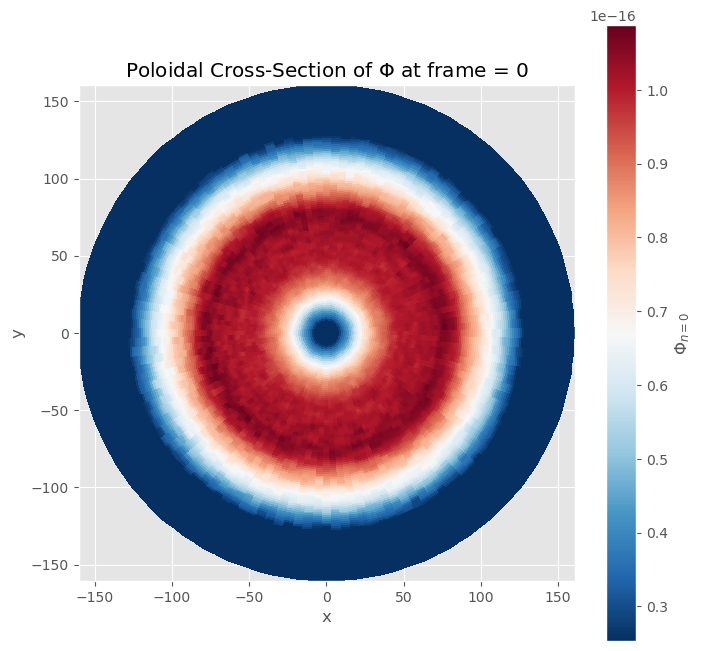

In [ ]:
# Generate Cartesian mesh-grid from radial and poloidal coordinate arrays.
sample_dataset = reader.fetch_data_from_h5(f"{simulation_path}/sp0/Phi2D/Phi2D_d00000.h5", dimensions = ["zeta", "r", "theta"]);
x_coords, y_coords = utils.generate_xy_grid(sample_dataset);

def load_phi_frame(step):

	filename = f"Phi2D_d{step:05d}.h5";
	path = f"{simulation_path}/sp0/Phi2D/{filename}";
	data = reader.fetch_data_from_h5(path, dimensions = ["zeta", "r", "theta"]);
	print(f"Loaded frame {step} from {filename}.");
	return data["Phirth_n0"].values;

# Animation logic.
figures, axes = plt.subplots(figsize = (8, 8));
initial_frame = load_phi_frame(0);
colourmesh = axes.pcolormesh(x_coords, y_coords, initial_frame, shading = "nearest", cmap = "RdBu_r");
colourmesh.set_clim(vmin = -np.min(initial_frame), vmax = np.max(initial_frame));
axes.set_aspect("equal");
axes.set_xlabel("x");
axes.set_ylabel("y");
title = axes.set_title(r"Poloidal Cross-Section of $\Phi_{n=0}$");
cbar = figures.colorbar(colourmesh, ax = axes, label = r"$\Phi_{n = 0}$");

def update(frame):

	current_frame = load_phi_frame(frame);
	axes.set_title(f"Poloidal Cross-Section of $\Phi$ at frame = {frame}");
	colourmesh.set_array(current_frame.ravel());
	return colourmesh;

anim = FuncAnimation(
	figures,
	update,
	frames = np.linspace(0, 26400, 5280, dtype = int),
	interval = 50,
	blit = False
);

anim.save(
	"flux_driven_phi2D.mp4",
	writer="ffmpeg",
	dpi=150
);